# Descomposición en Valores Singulares (SVD) y sus Aplicaciones en ML

**Elaborado por:** David Palacio J.  
**Correo:** davidpalacioj@gmail.com

---

**📘 Descripción:** Este notebook forma parte del módulo de álgebra lineal aplicada a Machine Learning, enfocado en la Descomposición en Valores Singulares (SVD) y sus aplicaciones prácticas.  
**📝 Nota:** Se recomienda abrir en Google Colab para mejor interactividad.

---

### Para ejecutar este notebook en Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dpalacioj/DataAI-Fundamentos-Aplicaciones/blob/main/InteligenciaArtificial/notebooks_teoria/2_SVD_aplicaciones_ML.ipynb)

## 🧠 Singular Value Decomposition (SVD) y compresión de imágenes

La **descomposición en valores singulares (SVD)** nos permite descomponer cualquier matriz \( A \) en tres matrices:

$$
A = U \Sigma V^T
$$

Esto es muy útil, por ejemplo, para **reducir la dimensionalidad** de los datos o **comprimir imágenes**.

En este ejemplo vamos a:
- Cargar una imagen.
- Convertirla a escala de grises.
- Aplicar SVD.
- Reconstruir la imagen usando solo los primeros **k valores singulares**.


In [1]:
# Importamos las librerías necesarias

import matplotlib.pyplot as plt
import numpy as np
from skimage import data, color
from skimage.transform import resize
from scipy.linalg import svd
import os

### 🖼️ Paso 1: Cargar y preprocesar la imagen

Vamos a cargar la famosa imagen de prueba `astronauta` que viene con `skimage`, y luego:

- La convertimos a escala de grises (para simplificar el análisis).
- La reducimos a un tamaño de 200x200 píxeles para facilitar el procesamiento.

In [2]:
# Cargar una imagen de ejemplo y convertirla a escala de grises

image = color.rgb2gray(data.astronaut())
image_resized = resize(image, (200, 200), anti_aliasing=True)

### 🔍 Paso 2: Aplicar la descomposición SVD

La imagen en escala de grises es una matriz. Vamos a aplicar SVD para descomponerla en:

- `U`: matriz de vectores ortogonales
- `S`: valores singulares
- `VT`: transpuesta de otra matriz ortogonal

Esto nos permitirá **reconstruir la imagen** usando solo algunos componentes.

In [3]:
# Aplicar SVD a la imagen
U, S, VT = svd(image_resized, full_matrices=False)

### 🔄 Paso 3: Reconstruir la imagen con diferentes cantidades de valores singulares

La función `reconstruct_image` reconstruye una versión aproximada de la imagen utilizando solo los primeros `k` valores singulares.

Esto nos permite ver cómo **a mayor k, mayor calidad**, pero también mayor tamaño de datos.

In [4]:
# Función para reconstruir la imagen usando los primeros k valores singulares
def reconstruct_image(U, S, VT, k):
    return np.dot(U[:, :k], np.dot(np.diag(S[:k]), VT[:k, :]))

### 📊 Paso 4: Mostrar las reconstrucciones para diferentes valores de `k`

Vamos a comparar visualmente cómo cambia la calidad de la imagen al variar el número de componentes \( k \).

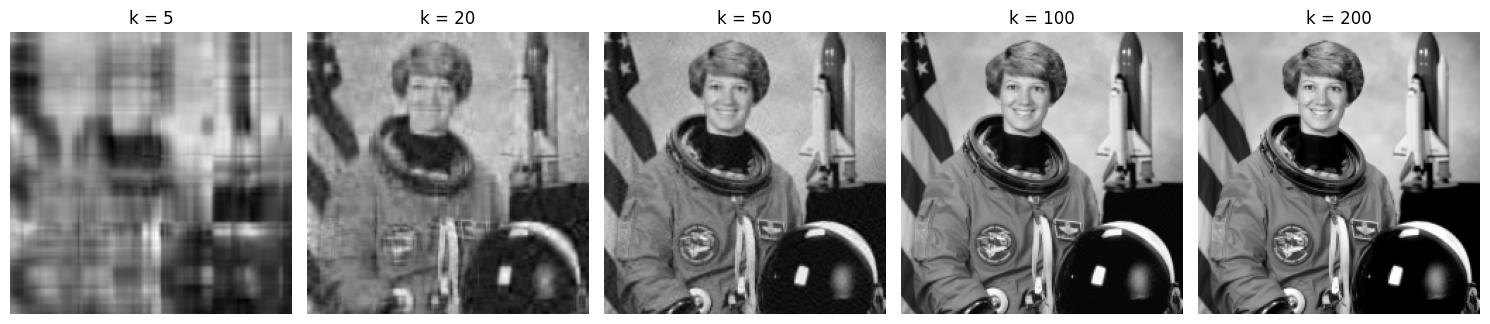

In [ ]:
# Lista de valores de k a usar
ks = [5, 20, 50, 100, 200]

# Crear la figura con subgráficos
fig, axes = plt.subplots(1, len(ks), figsize=(15, 4))

# Generar una imagen reconstruida para cada valor de k
for i, k in enumerate(ks):
    reconstructed = reconstruct_image(U, S, VT, k)
    axes[i].imshow(reconstructed, cmap='gray')
    axes[i].set_title(f'k = {k}')
    axes[i].axis('off')  # Quitar ejes para mejor visualización

plt.tight_layout()
plt.show()

## ✅ Conclusiones

- Con **pocos valores singulares (k = 5, 20)**, la imagen es muy borrosa pero reconocible.
- A medida que **aumenta k**, la imagen mejora considerablemente.
- Esta técnica permite **reducir el tamaño de almacenamiento** con **pérdida mínima de información visual**.
- ## 🧠 ¿Para qué sirve SVD en Machine Learning?

- **Reducción de dimensionalidad (PCA):**
  Conserva solo las direcciones más importantes de los datos, útil para simplificar sin perder información relevante.

- **Compresión de datos:**
  Almacena solo los componentes más significativos. Ideal para reducir el tamaño de imágenes, texto o matrices grandes.

- **Filtrado de ruido:**
  Elimina detalles no importantes (ruido) al descartar los valores singulares más pequeños.

🎯 En este ejemplo de imagen:
- Cada `k` representa una versión "más comprimida" de la imagen.
- Los valores grandes capturan la estructura general.
- Los valores pequeños tienden a ser ruido o detalles finos.
